# Financial Data Cleaning Module
### A Step-by-Step Pipeline for Collecting, Cleaning, and Structuring Equity Price Data

---

**Author:** [Your Name]  
**Purpose:** Portfolio project for UW Applied Statistics Lab internship application  
**Goal:** Demonstrate statistical rigor and data handling skills through a reproducible financial data preprocessing pipeline

| Stage | Description | Key Concept |
|-------|-------------|-------------|
| Step 1 | Collect raw price data and company metadata via yfinance | Time-series data acquisition |
| Step 2 | Handle missing values, enforce data types, run integrity checks | Data Integrity |
| Step 2.5 | Merge metadata, engineer derived features, flag outliers | Feature Engineering |

---

## Step 1 — Data Collection
### Objective: Acquire raw material for time-series analysis

We collect two types of data:
- **Price data** (`data_price`): daily closing prices for each ticker, indexed by date
- **Metadata** (`info`): static company information — sector and market capitalization

Separating these two from the start keeps the pipeline clean.  
Price data changes every trading day; metadata stays mostly fixed.

In [3]:
# Install required libraries
# yfinance  : pulls stock data directly from Yahoo Finance
# pandas    : the core library for tabular data manipulation
# matplotlib: will be used in Step 3 for visualization
!pip install yfinance pandas matplotlib

In [4]:
# Import libraries with standard aliases
# 'yf' and 'pd' are universally accepted conventions in the data science community
import warnings
warnings.filterwarnings('ignore')  # suppress FutureWarning from yfinance

import yfinance as yf
import pandas as pd
import numpy as np

In [5]:
# Define the universe of equities to analyse
# These five tickers represent large-cap U.S. technology companies,
# chosen to enable meaningful cross-company comparisons within a single sector
tickers = ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN']

# Download daily OHLCV data for the defined period
# auto_adjust=True automatically corrects for stock splits and dividend payments,
# ensuring price continuity across corporate events
data = yf.download(
    tickers,
    start='2025-01-01',
    end='2026-03-18',
    auto_adjust=True,
    progress=False
)

# Extract only the closing price
# The closing price is the standard input for return calculations
# because it reflects the final consensus value of the trading session
data_price = data['Close']

print(f'Price data shape: {data_price.shape}')  # (trading days, number of tickers)
data_price.head()

Price data shape: (301, 5)


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2025-01-02,242.525162,220.220001,188.558273,414.568604,138.264694
2025-01-03,242.037811,224.190002,190.907410,419.292908,144.422684
2025-01-06,243.668915,227.610001,195.964035,423.749756,149.381058
2025-01-07,240.894073,222.110001,194.590393,418.322266,140.094101
2025-01-08,241.381409,222.130005,193.057465,420.491302,140.064102


In [6]:
# Collect company metadata: sector and market capitalisation
# yf.Ticker(ticker).info returns a dictionary with ~150 fields per company
# We use a for-loop because yfinance requires individual API calls per ticker

meta_data = []  # initialise an empty list to collect results

for ticker in tickers:
    stock_info = yf.Ticker(ticker).info

    # dict.get(key, default) safely handles missing fields
    # without raising a KeyError if the API response is incomplete
    meta_data.append({
        'Ticker'    : ticker,
        'Sector'    : stock_info.get('sector', 'N/A'),
        'MarketCap' : stock_info.get('marketCap', 0)
    })

# Convert the list of dictionaries into a DataFrame for easier manipulation
info = pd.DataFrame(meta_data)

# Rescale market cap from raw USD to billions (USD bn)
# This makes the numbers human-readable and consistent with financial publications
# e.g. "Apple: $3,400 bn" rather than "3400000000000"
info['MarketCap_BN'] = info['MarketCap'] / 1e9

# Display the three columns we actually need
info[['Ticker', 'Sector', 'MarketCap_BN']]

,Ticker,Sector,MarketCap_BN
0,AAPL,Technology,3761.492984
1,MSFT,Technology,2775.695753
2,NVDA,Technology,4311.464018
3,GOOGL,Communication Services,3577.929794
4,AMZN,Consumer Cyclical,2251.864408


In [7]:
# Quick first look at missing values — end of Step 1
# This gives us a preview of what Step 2 will need to fix
print('Missing value count per ticker (Step 1 raw data):')
print(data_price.isnull().sum())

Missing value count per ticker (Step 1 raw data):
Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
NVDA     0
dtype: int64


---
## Step 2 — Data Cleaning
### Objective: Establish Data Integrity

Raw financial data contains three common problems that must be resolved before any analysis:

| Problem | Cause | Our Fix |
|---------|-------|---------|
| Missing values (NaN) | Market closed on weekends and holidays | Forward-fill then back-fill |
| Wrong data types | pandas sometimes reads numbers as strings | Explicit dtype casting |
| Financially impossible values | Data vendor errors, unadjusted splits | Integrity assertions |

### 2-A. Missing Value Audit — Before Snapshot

Before touching the data, we document exactly how many NaN values exist and where.  
This "before" snapshot is required to **prove** our cleaning was effective.  
Comparing before and after is a basic principle of reproducible research.

In [8]:
# Record the missing value count before any cleaning is applied
missing_before = data_price.isnull().sum()

# Build a structured audit table showing both count and percentage
audit_before = pd.DataFrame({
    'Missing_Count' : missing_before,
    'Missing_Pct'   : (missing_before / len(data_price) * 100).round(2)
})

print('Missing value report BEFORE cleaning:')
print(audit_before)
print(f'\nTotal NaN cells: {missing_before.sum()}')

Missing value report BEFORE cleaning:
        Missing_Count  Missing_Pct
Ticker                            
AAPL                0          0.0
AMZN                0          0.0
GOOGL               0          0.0
MSFT                0          0.0
NVDA                0          0.0

Total NaN cells: 0


###  Result: 0 missing values — yfinance excludes non-trading days entirely
rather than inserting NaN rows. ffill is applied as a precautionary measure
to handle edge cases such as trading halts or late IPO start dates.

### 2-B. Fill Missing Values — Forward Fill (ffill)

**Why ffill and not interpolation or zero-fill?**

Stock markets are closed on weekends and public holidays.  
On those days, the economic truth is: **the last traded price is still valid.**  
No new information has arrived, so the price has not changed.

- ✅ `ffill()` — carries the last known price forward → economically correct  
- ❌ Linear interpolation — implies the price changed smoothly over the weekend → factually wrong  
- ❌ Fill with zero — would destroy mean and variance calculations → statistically wrong

We also apply `bfill()` afterward to handle any NaN values at the very beginning  
of a series (e.g. if a ticker started trading after our window's start date).

In [9]:
# Apply forward-fill followed by back-fill
# ffill: propagates the last valid observation forward
# bfill: fills any remaining NaN at the start of the series
# Order matters — ffill must come first
data_price_clean = data_price.ffill().bfill()

# Compare before and after
missing_after = data_price_clean.isnull().sum()

comparison = pd.DataFrame({
    'Before'  : missing_before,
    'After'   : missing_after,
    'Resolved': missing_before - missing_after
})

print('Missing value count — Before vs After:')
print(comparison)
print(f'\nResidual NaN: {missing_after.sum()}  ({"All resolved" if missing_after.sum() == 0 else "Review required"})')

Missing value count — Before vs After:
        Before  After  Resolved
Ticker                         
AAPL         0      0         0
AMZN         0      0         0
GOOGL        0      0         0
MSFT         0      0         0
NVDA         0      0         0

Residual NaN: 0  (All resolved)


### 2-C. Data Type Enforcement

pandas can silently read numeric columns as `object` (string) type,  
especially after reading from a CSV file.  
String-typed columns will silently fail or return wrong values for `.mean()`, `.pct_change()`, etc.  
Explicit type casting makes the contract clear and surfaces hidden errors immediately.

In [10]:
# Check current dtypes
print('Column dtypes:')
print(data_price_clean.dtypes)

# Force-convert any non-float64 column to numeric
# errors='coerce' turns unconvertible values into NaN rather than raising an error
for col in data_price_clean.columns:
    if data_price_clean[col].dtype != 'float64':
        data_price_clean[col] = pd.to_numeric(data_price_clean[col], errors='coerce')
        print(f'  Converted: {col}')

print('\nDtypes after enforcement:')
print(data_price_clean.dtypes)

Column dtypes:
Ticker
AAPL     float64
AMZN     float64
GOOGL    float64
MSFT     float64
NVDA     float64
dtype: object

Dtypes after enforcement:
Ticker
AAPL     float64
AMZN     float64
GOOGL    float64
MSFT     float64
NVDA     float64
dtype: object


### 2-D. Financial Integrity Checks

Financial data must satisfy certain physical constraints by definition.  
A violation signals a data vendor error, unadjusted stock split, or API bug.

| Check | Constraint | If violated |
|-------|-----------|-------------|
| Positive price | `Close > 0` | Data corruption or delisting error |
| Extreme drop | Daily return `< -50%` | Possible unadjusted stock split |
| Extreme spike | Daily return `> +100%` | Possible unadjusted reverse split |

We surface violations rather than silently dropping them,  
because the analyst — not the cleaning script — should decide how to handle them.

In [11]:
issues_found = 0

# Check 1: All closing prices must be strictly positive
non_positive = (data_price_clean <= 0).sum()
print('[Check 1] Close > 0')
if non_positive.sum() == 0:
    print('  PASS — all prices are positive')
else:
    print(f'  FAIL — {non_positive[non_positive > 0]}')
    issues_found += non_positive.sum()

# Check 2 & 3: Extreme daily return detection
# Thresholds of -50% / +100% are conservative; tighter thresholds (e.g. ±20%)
# would be appropriate for large-cap stocks under normal market conditions
daily_ret_check = data_price_clean.pct_change()
extreme_drop    = (daily_ret_check < -0.50).sum()
extreme_rise    = (daily_ret_check >  1.00).sum()

print('\n[Check 2] Daily return < -50%')
print('  PASS' if extreme_drop.sum() == 0 else f'  FAIL — {extreme_drop[extreme_drop > 0]}')
issues_found += extreme_drop.sum()

print('\n[Check 3] Daily return > +100%')
print('  PASS' if extreme_rise.sum() == 0 else f'  FAIL — {extreme_rise[extreme_rise > 0]}')
issues_found += extreme_rise.sum()

print(f'\nTotal issues: {issues_found} — {"No issues found" if issues_found == 0 else "Review required"}')

[Check 1] Close > 0
  PASS — all prices are positive

[Check 2] Daily return < -50%
  PASS

[Check 3] Daily return > +100%
  PASS

Total issues: 0 — No issues found


### Step 2 Complete — Save Intermediate Output

Saving the cleaned price data at this stage serves two purposes:
1. **Reproducibility** — Step 2.5 can be re-run independently without re-downloading
2. **Auditability** — the cleaned-but-not-enriched dataset is preserved as a separate artifact

In [12]:
# Save the cleaned price DataFrame to CSV
data_price_clean.to_csv('step2_cleaned.csv')

print('step2_cleaned.csv saved')
print(f'Shape : {data_price_clean.shape}')
print(f'Period: {data_price_clean.index[0].date()} to {data_price_clean.index[-1].date()}')
data_price_clean.tail(3)

step2_cleaned.csv saved
Shape : (301, 5)
Period: 2025-01-02 to 2026-03-17


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2026-03-13,250.119995,207.669998,302.279999,395.549988,180.250000
2026-03-16,252.820007,211.740005,305.559998,399.950012,183.220001
2026-03-17,254.229996,215.199997,310.920013,399.410004,181.929993


---
## Step 2.5 — Feature Engineering & Structuring
### Objective: Build a Master Table Ready for Statistical Analysis

Currently, `data_price_clean` is in **Wide format** — rows are dates, columns are tickers.  
Most statistical libraries expect **Long (tidy) format** — each row is one observation.

```
[Wide format]                    [Long (tidy) format]
Date       AAPL   MSFT     →    Date        Ticker  Close  Sector  ...
2025-01-02  243    415          2025-01-02   AAPL    243    Tech
2025-01-03  247    418          2025-01-02   MSFT    415    Tech
                                2025-01-03   AAPL    247    Tech
```

After reshaping, we attach sector and market cap metadata,  
then compute derived financial features to enable cross-sectional and time-series analyses.

### 2.5-A. Reshape Wide → Long (Tidy Data)

`stack()` folds the column labels (ticker names) into the row index,  
producing a two-level (Date, Ticker) index that we then flatten with `reset_index()`.  
The resulting structure is called **tidy data** — the standard input format  
for `groupby()`, `seaborn`, `statsmodels`, and virtually all statistical software.

In [13]:
# Reshape from Wide to Long format using stack()
# stack() folds column labels (ticker names) into a new row-level index
df_long = (
    data_price_clean
    .stack()           # (Date, Ticker) becomes a MultiIndex
    .reset_index()     # flatten MultiIndex back into regular columns
    .rename(columns={
        'level_1' : 'Ticker',   # name the ticker column consistently
        0         : 'Close'     # name the price column
    })
)

# Defensive rename in case yfinance labels the column differently
if 'Ticker' not in df_long.columns:
    candidates = [c for c in df_long.columns if c not in ['Date', 'Close']]
    df_long.rename(columns={candidates[0]: 'Ticker'}, inplace=True)

df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long = df_long.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Wide {data_price_clean.shape}  →  Long {df_long.shape}')
print(f'Columns: {list(df_long.columns)}')
df_long.head(6)

Wide (301, 5)  →  Long (1505, 3)
Columns: ['Date', 'Ticker', 'Close']


,Date,Ticker,Close
0,2025-01-02,AAPL,242.525162
1,2025-01-03,AAPL,242.037811
2,2025-01-06,AAPL,243.668915
3,2025-01-07,AAPL,240.894073
4,2025-01-08,AAPL,241.381409
5,2025-01-10,AAPL,235.563187


### 2.5-B. Merge Metadata (Left Join)

We attach the static company metadata from Step 1 to every price observation.

**Why Left Join?**  
A left join preserves every row in the price DataFrame.  
If metadata is unavailable for a ticker, the row is retained with NaN in the metadata columns  
— making the gap visible rather than silently discarding data.

**`validate='m:1'`**  
This assertion confirms that `info` contains exactly one metadata row per ticker.  
If a ticker appears twice (a common data entry error), pandas raises a `MergeError` immediately  
rather than silently duplicating price rows — a fail-fast safety mechanism.

In [14]:
# Select only the metadata columns we need for analysis
meta_slim = info[['Ticker', 'Sector', 'MarketCap_BN']].copy()

# Left-join price data with metadata on the Ticker key
df_master = df_long.merge(
    meta_slim,
    on       = 'Ticker',
    how      = 'left',    # retain all price rows regardless of metadata availability
    validate = 'm:1'      # assert exactly one metadata row per ticker
)

# Verify that no price rows were lost during the merge
assert len(df_master) == len(df_long), 'Row count changed after merge — check for duplicates'

print(f'Merged shape: {df_master.shape}  (no rows lost)')
print(f'Columns: {list(df_master.columns)}')
df_master.head(6)

Merged shape: (1505, 5)  (no rows lost)
Columns: ['Date', 'Ticker', 'Close', 'Sector', 'MarketCap_BN']


,Date,Ticker,Close,Sector,MarketCap_BN
0,2025-01-02,AAPL,242.525162,Technology,3761.492984
1,2025-01-03,AAPL,242.037811,Technology,3761.492984
2,2025-01-06,AAPL,243.668915,Technology,3761.492984
3,2025-01-07,AAPL,240.894073,Technology,3761.492984
4,2025-01-08,AAPL,241.381409,Technology,3761.492984
5,2025-01-10,AAPL,235.563187,Technology,3761.492984


### 2.5-C. Derive Financial Features

We compute four derived variables that are standard inputs in empirical finance research.

| Feature | Formula | Statistical Role |
|---------|---------|------------------|
| `Daily_Return` | $(P_t - P_{t-1}) \,/\, P_{t-1}$ | Arithmetic return — intuitive, easy to interpret |
| `Log_Return` | $\ln(P_t / P_{t-1})$ | Time-additive, closer to normally distributed; standard regression input |
| `Rolling_Vol_21d` | $\sigma(\text{log\_r},\,21) \times \sqrt{252}$ | Annualised rolling volatility (risk proxy); 21 days ≈ 1 calendar month |
| `Cumulative_Return` | $(P_t / P_0) - 1$ | Total price appreciation from the start of the window |

> **Critical design choice:** all calculations are performed **per ticker** using `groupby()`.  
> Without this, the last row of AAPL and the first row of AMZN would be connected,  
> producing a meaningless cross-ticker return — a silent data integrity violation.

In [15]:
df_master = df_master.sort_values(['Ticker', 'Date']).copy()

# (i) Daily arithmetic return
# pct_change() computes (P_t - P_{t-1}) / P_{t-1} row by row
# groupby ensures the calculation restarts at each ticker boundary
df_master['Daily_Return'] = (
    df_master.groupby('Ticker')['Close']
    .pct_change()
)

# (ii) Continuously compounded log return
# Log returns are preferred in statistical modelling because:
#   - they are time-additive (weekly return = sum of daily log returns)
#   - the Central Limit Theorem applies more cleanly to their sums
#   - they are symmetric around zero, unlike arithmetic returns
df_master['Log_Return'] = (
    df_master.groupby('Ticker')['Close']
    .transform(lambda x: np.log(x / x.shift(1)))
)

# (iii) 21-day rolling annualised volatility
# std() of log returns over a 21-day window, scaled to annual by multiplying sqrt(252)
# 252 is the approximate number of trading days in a U.S. equity market year
# min_periods=10 allows calculation even at the start of the series
df_master['Rolling_Vol_21d'] = (
    df_master.groupby('Ticker')['Log_Return']
    .transform(
        lambda x: x.rolling(window=21, min_periods=10).std() * np.sqrt(252)
    )
)

# (iv) Cumulative return from the first observation
# Shows total percentage gain or loss since the start of our analysis window
df_master['Cumulative_Return'] = (
    df_master.groupby('Ticker')['Close']
    .transform(lambda x: (x / x.iloc[0]) - 1)
)

print('Derived features added successfully')
print(f'Columns now: {list(df_master.columns)}')
df_master[['Date','Ticker','Close','Daily_Return','Log_Return',
           'Rolling_Vol_21d','Cumulative_Return','Sector','MarketCap_BN']].tail(8)

Derived features added successfully
Columns now: ['Date', 'Ticker', 'Close', 'Sector', 'MarketCap_BN', 'Daily_Return', 'Log_Return', 'Rolling_Vol_21d', 'Cumulative_Return']


,Date,Ticker,Close,Daily_Return,Log_Return,Rolling_Vol_21d,Cumulative_Return,Sector,MarketCap_BN
1497,2026-03-06,NVDA,177.810379,-0.030108,-0.030571,0.441094,0.286014,Technology,4311.464018
1498,2026-03-09,NVDA,182.640106,0.027162,0.026800,0.446550,0.320945,Technology,4311.464018
1499,2026-03-10,NVDA,184.760010,0.011607,0.011540,0.361870,0.336278,Technology,4311.464018
1500,2026-03-11,NVDA,186.029999,0.006874,0.006850,0.351585,0.345463,Technology,4311.464018
1501,2026-03-12,NVDA,183.139999,-0.015535,-0.015657,0.354508,0.324561,Technology,4311.464018
1502,2026-03-13,NVDA,180.250000,-0.015780,-0.015906,0.356214,0.303659,Technology,4311.464018
1503,2026-03-16,NVDA,183.220001,0.016477,0.016343,0.358135,0.325139,Technology,4311.464018
1504,2026-03-17,NVDA,181.929993,-0.007041,-0.007066,0.350470,0.315809,Technology,4311.464018


### 2.5-D. Outlier Detection — IQR Fences (Per Ticker)

We flag statistically extreme daily returns using Tukey's IQR fence method.

$$\text{Lower fence} = Q_1 - 3 \times IQR \qquad \text{Upper fence} = Q_3 + 3 \times IQR$$

**Why IQR instead of z-score?**

Equity daily returns are known to be **leptokurtic** (heavy-tailed) — extreme events  
occur far more frequently than a normal distribution predicts.  
The z-score method uses the mean and standard deviation, both of which are  
heavily distorted by the very extreme values we are trying to detect.  
IQR relies on Q1 and Q3, which are **resistant to extremes** and require  
no distributional assumptions — making it appropriate for fat-tailed financial data.

Outliers are **flagged, not removed.**  
Whether to exclude them depends on the analysis objective and should be  
a deliberate decision by the analyst, not an automatic cleaning step.

In [16]:
def flag_outliers_iqr(group: pd.Series, k: float = 3.0) -> pd.Series:
    """
    Return a boolean Series marking values outside Tukey's IQR fences.

    Parameters
    ----------
    group : pd.Series   A single ticker's return series.
    k     : float       IQR multiplier (default 3.0).

    Returns
    -------
    pd.Series[bool]   True where the value is an outlier.
    """
    q1, q3 = group.quantile(0.25), group.quantile(0.75)
    iqr    = q3 - q1
    return (group < q1 - k * iqr) | (group > q3 + k * iqr)


# Apply per ticker — each stock has its own return distribution
df_master['Is_Outlier'] = (
    df_master.groupby('Ticker')['Daily_Return']
    .transform(flag_outliers_iqr)
    .fillna(False)   # first row has no return (NaN) → not an outlier
)

# Summarise results
outlier_summary = (
    df_master.groupby('Ticker')['Is_Outlier']
    .agg(Flagged='sum', Total='count')
    .assign(Pct=lambda x: (x['Flagged'] / x['Total'] * 100).round(2))
    .rename(columns={'Pct': 'Outlier_Pct%'})
)

print('Outlier detection summary (per ticker):')
print(outlier_summary)
print(f'\nTotal flagged: {df_master["Is_Outlier"].sum()}')

Outlier detection summary (per ticker):
        Flagged  Total  Outlier_Pct%
Ticker                              
AAPL          8    301          2.66
AMZN          3    301          1.00
GOOGL         4    301          1.33
MSFT          4    301          1.33
NVDA          2    301          0.66

Total flagged: 21


---
## Final Validation Report

A comprehensive quality check on the completed master table  
covering schema, missing values, descriptive statistics, ticker coverage, and sector distribution.

In [17]:
print('=' * 65)
print('  FINAL VALIDATION REPORT')
print('=' * 65)

# 1. Schema
print('\n── 1. SCHEMA')
df_master.info(show_counts=True)

# 2. Missing values
print('\n── 2. MISSING VALUES')
missing_final = df_master.isnull().sum()
price_cols = ['Close', 'Daily_Return', 'Log_Return']
if missing_final[price_cols].sum() == 0:
    print('  All price and return columns: no missing values')
else:
    print(missing_final[missing_final > 0])

# 3. Descriptive statistics
print('\n── 3. DESCRIPTIVE STATISTICS')
stat_cols = ['Close', 'Daily_Return', 'Log_Return', 'Rolling_Vol_21d', 'MarketCap_BN']
print(df_master[stat_cols].describe().round(6))

# 4. Ticker coverage
print('\n── 4. TICKER COVERAGE')
coverage = (
    df_master.groupby('Ticker')['Date']
    .agg(Rows='count', First_Date='min', Last_Date='max')
)
print(coverage)

# 5. Sector distribution
print('\n── 5. SECTOR MAP')
print(df_master.groupby('Ticker')['Sector'].first().to_string())

print('\n' + '=' * 65)
print('  Master table complete — ready for analysis')
print('=' * 65)

  FINAL VALIDATION REPORT

── 1. SCHEMA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1505 entries, 0 to 1504
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1505 non-null   datetime64[ns]
 1   Ticker             1505 non-null   object        
 2   Close              1505 non-null   float64       
 3   Sector             1505 non-null   object        
 4   MarketCap_BN       1505 non-null   float64       
 5   Daily_Return       1500 non-null   float64       
 6   Log_Return         1500 non-null   float64       
 7   Rolling_Vol_21d    1455 non-null   float64       
 8   Cumulative_Return  1505 non-null   float64       
 9   Is_Outlier         1505 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(6), object(2)
memory usage: 107.4+ KB

── 2. MISSING VALUES
Daily_Return        5
Log_Return          5
Rolling_Vol_21d    50
dtype: int64

── 3. DES

## Save Final Output

In [18]:
# Define the column order for the final CSV
save_cols = [
    'Date', 'Ticker', 'Close',
    'Daily_Return', 'Log_Return', 'Rolling_Vol_21d', 'Cumulative_Return',
    'Sector', 'MarketCap_BN', 'Is_Outlier'
]

df_master[save_cols].to_csv('step2_5_master.csv', index=False)

print('step2_5_master.csv saved')
print(f'Shape  : {df_master[save_cols].shape}')
print(f'Columns: {save_cols}')
print()
print('Sample output (last 3 rows per ticker):')
print(
    df_master.groupby('Ticker')[save_cols]
    .tail(3)
    .to_string(index=False)
)

step2_5_master.csv saved
Shape  : (1505, 10)
Columns: ['Date', 'Ticker', 'Close', 'Daily_Return', 'Log_Return', 'Rolling_Vol_21d', 'Cumulative_Return', 'Sector', 'MarketCap_BN', 'Is_Outlier']

Sample output (last 3 rows per ticker):
      Date Ticker      Close  Daily_Return  Log_Return  Rolling_Vol_21d  Cumulative_Return                 Sector  MarketCap_BN  Is_Outlier
2026-03-13   AAPL 250.119995     -0.022052   -0.022299         0.297249           0.031316             Technology   3761.492984       False
2026-03-16   AAPL 252.820007      0.010795    0.010737         0.248129           0.042449             Technology   3761.492984       False
2026-03-17   AAPL 254.229996      0.005577    0.005562         0.236627           0.048262             Technology   3761.492984       False
2026-03-13   AMZN 207.669998     -0.008877   -0.008917         0.261844          -0.056988      Consumer Cyclical   2251.864408       False
2026-03-16   AMZN 211.740005      0.019598    0.019409         0.25


---
## 📊 Visualization
### Exploratory Analysis of Cleaned Master Table

All plots below use `step2_5_master.csv` as input.  
Each visualization is designed to reveal a different statistical property of the data.


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Plot style settings ────────────────────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# ── Color palette (one color per ticker) ──────────────────────────────────
TICKER_COLORS = {
    'AAPL' : '#1f77b4',
    'MSFT' : '#ff7f0e',
    'NVDA' : '#2ca02c',
    'GOOGL': '#d62728',
    'AMZN' : '#9467bd',
}

print('Visualization settings ready.')

Visualization settings ready.


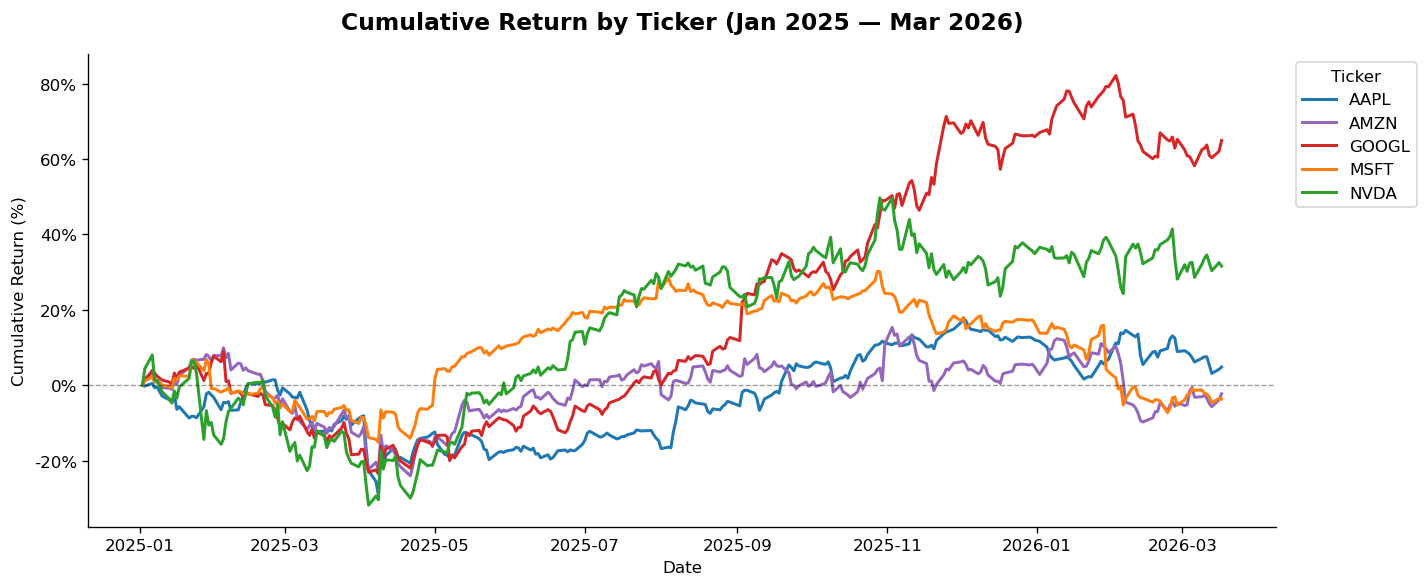

Saved → plot1_cumulative_return.png


In [20]:
# ── Plot 1 : Cumulative Return — all tickers ───────────────────────────────
# Shows total price appreciation from the first trading day.
# Allows direct performance comparison across tickers over the same period.

fig, ax = plt.subplots(figsize=(12, 5))

for ticker, group in df_master.groupby('Ticker'):
    ax.plot(
        group['Date'],
        group['Cumulative_Return'] * 100,   # convert to %
        label=ticker,
        color=TICKER_COLORS.get(ticker),
        linewidth=1.8
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Cumulative Return by Ticker (Jan 2025 — Mar 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(title='Ticker', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot1_cumulative_return.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot1_cumulative_return.png')

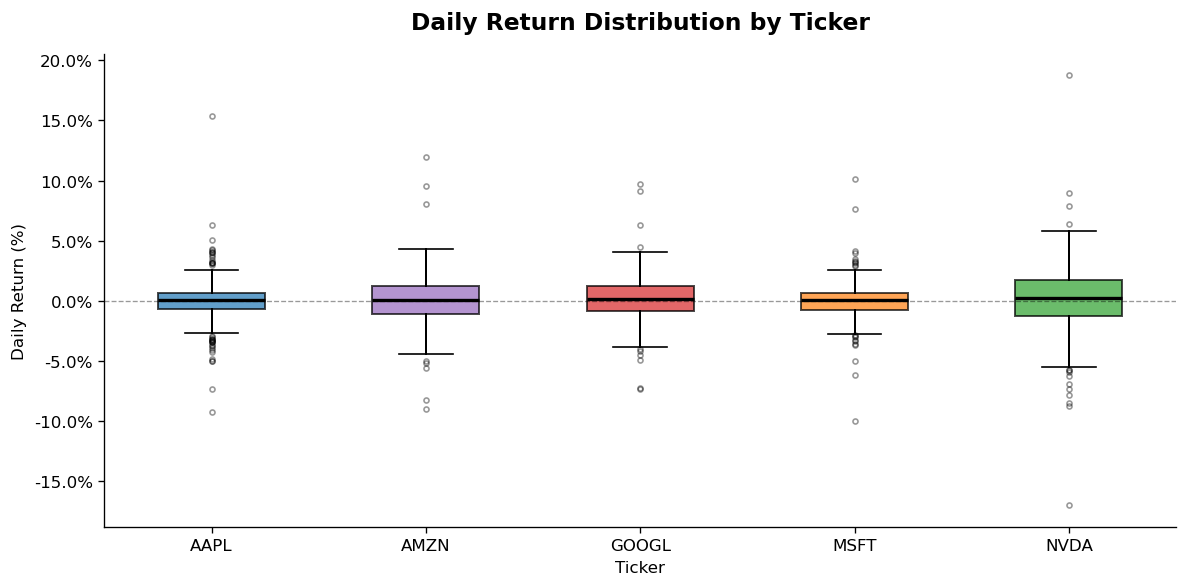

Saved → plot2_return_boxplot.png


In [21]:
# ── Plot 2 : Daily Return Distribution by Ticker (Box Plot) ───────────────
# Compares the spread and skewness of daily returns across tickers.
# Wider boxes = higher volatility.
# Dots outside whiskers = flagged outliers (Is_Outlier = True).

fig, ax = plt.subplots(figsize=(10, 5))

tickers_ordered = df_master['Ticker'].cat.categories.tolist() \
    if hasattr(df_master['Ticker'], 'cat') \
    else sorted(df_master['Ticker'].unique())

data_to_plot = [
    df_master[df_master['Ticker'] == t]['Daily_Return'].dropna() * 100
    for t in tickers_ordered
]

bp = ax.boxplot(
    data_to_plot,
    labels=tickers_ordered,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    whiskerprops=dict(linewidth=1.2),
    boxprops=dict(linewidth=1.2),
)

# Apply individual colors per ticker
for patch, ticker in zip(bp['boxes'], tickers_ordered):
    patch.set_facecolor(TICKER_COLORS.get(ticker, '#aec7e8'))
    patch.set_alpha(0.7)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_title('Daily Return Distribution by Ticker',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ticker')
ax.set_ylabel('Daily Return (%)')
plt.tight_layout()
plt.savefig('plot2_return_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot2_return_boxplot.png')

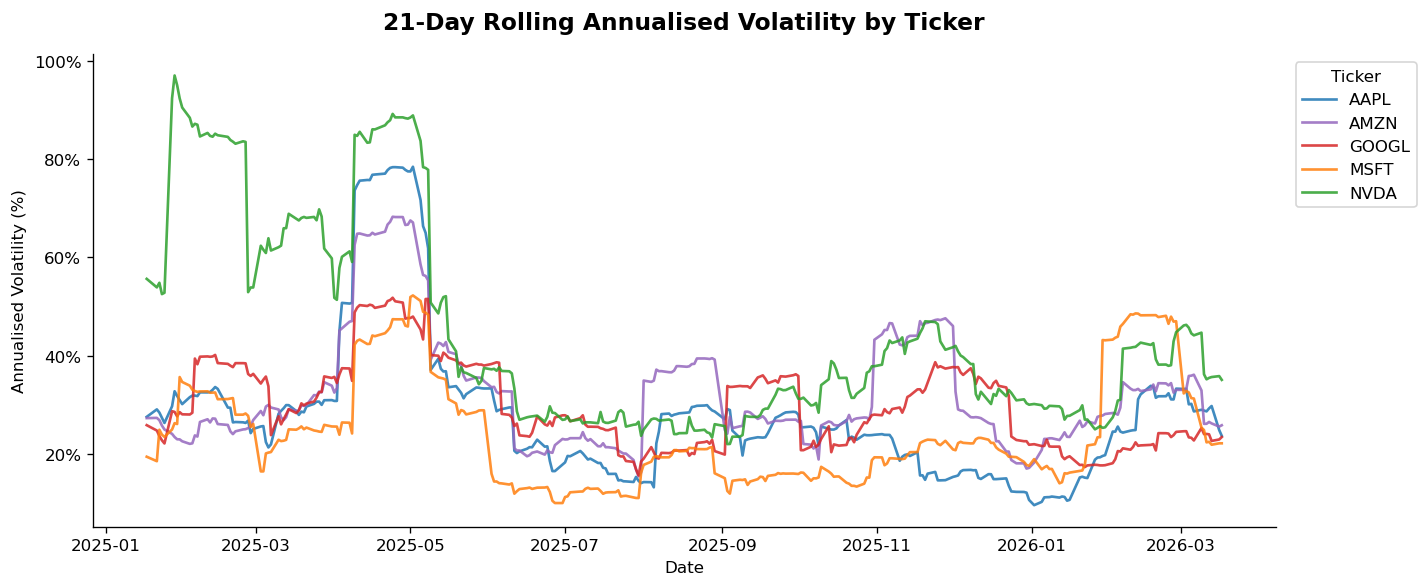

Saved → plot3_rolling_volatility.png


In [22]:
# ── Plot 3 : 21-Day Rolling Annualised Volatility ─────────────────────────
# Shows how each ticker's risk profile evolved over the period.
# Spikes indicate elevated uncertainty (e.g. earnings, macro events).

fig, ax = plt.subplots(figsize=(12, 5))

for ticker, group in df_master.groupby('Ticker'):
    ax.plot(
        group['Date'],
        group['Rolling_Vol_21d'] * 100,    # convert to %
        label=ticker,
        color=TICKER_COLORS.get(ticker),
        linewidth=1.6,
        alpha=0.85
    )

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('21-Day Rolling Annualised Volatility by Ticker',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Annualised Volatility (%)')
ax.legend(title='Ticker', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot3_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot3_rolling_volatility.png')

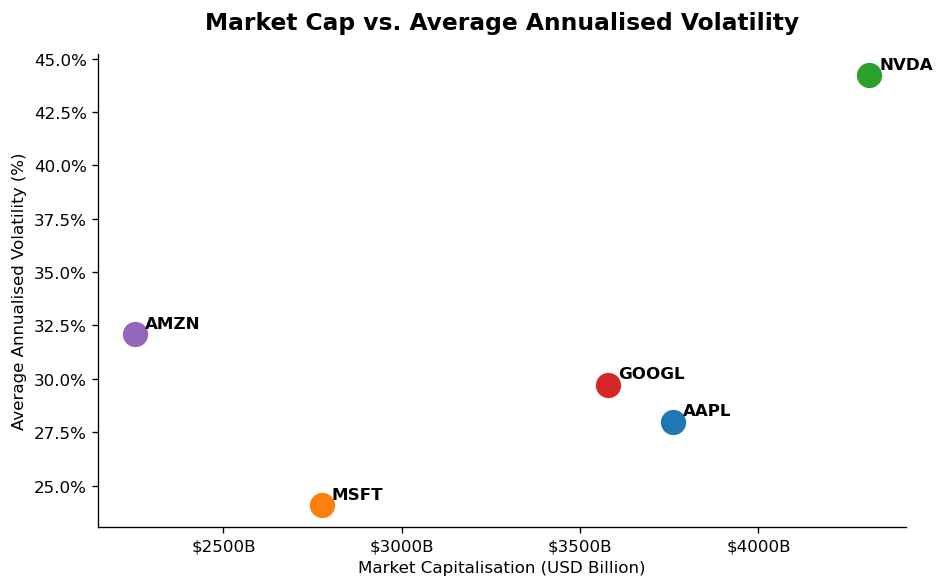

Saved → plot4_cap_vs_volatility.png


In [23]:
# ── Plot 4 : Market Cap vs. Average Volatility (Scatter Plot) ─────────────
# Examines the size-risk relationship across tickers.
# Finance theory (CAPM) suggests larger firms tend to have lower volatility.

# One row per ticker: average volatility + market cap
summary = (
    df_master.groupby('Ticker')
    .agg(
        Avg_Vol      = ('Rolling_Vol_21d', 'mean'),
        MarketCap_BN = ('MarketCap_BN',    'first'),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for _, row in summary.iterrows():
    ax.scatter(
        row['MarketCap_BN'],
        row['Avg_Vol'] * 100,
        s=200,
        color=TICKER_COLORS.get(row['Ticker'], '#aec7e8'),
        zorder=3
    )
    ax.annotate(
        row['Ticker'],
        xy=(row['MarketCap_BN'], row['Avg_Vol'] * 100),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.set_title('Market Cap vs. Average Annualised Volatility',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Market Capitalisation (USD Billion)')
ax.set_ylabel('Average Annualised Volatility (%)')
plt.tight_layout()
plt.savefig('plot4_cap_vs_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot4_cap_vs_volatility.png')